# Práctica 1 Aprendizaje Automático: Predicción de Subscripción a un Producto Bancario

**Miembros del equipo:**
    Jose Luis Mejía 1: (NIA:100472712)
    Mireya Luque 2: (NIA:100495927)

____________________________________________________________________________________________________

Declaración de uso de IA Generativa

In [ ]:
%pip install matplotlib

In [ ]:
### IMPORTS PARA EL NOTEBOOK

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import pandas as pd
import numpy as np
import time

## Carga inicial de datos y configuración de reproducibilidad

En este bloque se fija una **semilla aleatoria** usando un NIA del equipo (**100495927**) con `np.random.seed(NIA)`.  
Esto garantiza que cualquier proceso que dependa de aleatoriedad (por ejemplo, particiones train test o validación cruzada) produzca los mismos resultados cada vez que se ejecute el notebook.

A continuación, se define la ruta del archivo `bank_09.pkl` y se carga el dataset con `pd.read_pickle`.

Finalmente, se muestra:
- La **dimensión del dataset** (número de filas y columnas) para tener una visión general.
- Las **primeras filas** con `head()` para comprobar que la carga se ha realizado correctamente y ver un ejemplo del contenido.

In [4]:
#Fijamos la semilla con un NIA del equipo
NIA = 100495927
np.random.seed(NIA)

#Cargamos los datos
ruta_archivo = 'Datos/bank_09.pkl'
df = pd.read_pickle(ruta_archivo)

#Mostramos la información
print("Dimensiones del dataset:", df.shape)
display(df.head())

Dimensiones del dataset: (11000, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


## EDA simplificado: estructura, tipos de variables y calidad de datos

En este bloque se realiza un **EDA simplificado** (Exploratory Data Analysis) para obtener una visión general del dataset y detectar posibles problemas de calidad de datos que afecten al preprocesamiento y al modelado.

### 1. Instancias y variables
Se imprime el número de **filas** (instancias) y **columnas** (variables) del dataset usando `df.shape`. Esto permite conocer el tamaño del conjunto de datos con el que se va a trabajar.

### 2. Tipos de variables
Se separan las variables en dos grandes grupos:
- **Numéricas**: columnas de tipo `int64` o `float64`.
- **Categóricas**: columnas de tipo `object`, `category` o `bool`.

Esto es importante porque cada tipo de variable suele requerir un preprocesamiento distinto (por ejemplo, escalado para numéricas y codificación para categóricas).

### 3. Valores faltantes
Se calcula cuántos valores nulos hay en cada columna con `df.isnull().sum()`.  
Después, se filtran solo aquellas columnas que realmente tengan valores faltantes (más de 0).  
Si no hay columnas con nulos, se indica explícitamente.

### 4. Columnas constantes
Se detectan columnas con **un único valor** (o sin variación) calculando el número de valores únicos con `nunique()`.  
Las columnas constantes no aportan información predictiva y, normalmente, se pueden eliminar.

### 5. Alta cardinalidad en variables categóricas
Se identifican variables categóricas con **más de 10 valores únicos**.  
Este punto es relevante porque la alta cardinalidad puede complicar técnicas como el one hot encoding, aumentando mucho la dimensión del dataset y el riesgo de sobreajuste.

### 6. Tipo de problema y balanceo de la variable objetivo
Se confirma que el problema es de **clasificación binaria**, ya que la variable objetivo es `deposit` (suscribe o no suscribe).  
Además, se calcula el porcentaje de cada clase con `value_counts(normalize=True)` para comprobar si el dataset está **balanceado o desbalanceado**, lo cual puede afectar tanto a la métrica elegida como al rendimiento de algunos modelos.

### 7. Análisis particular de `pdays`
Se analiza específicamente la variable `pdays`, que representa el número de días desde el último contacto en una campaña anterior.
Para ello:
- Se muestran estadísticos descriptivos (`describe()`).
- Se listan los valores más frecuentes (`value_counts().head()`).
- Se calcula el porcentaje de clientes con `pdays = -1`, que según la descripción indica **sin contacto previo o desconocido**.


In [5]:
print("--- 1. INSTANCIAS Y VARIABLES ---")
print(f"Número de instancias (filas): {df.shape[0]}")
print(f"Número de variables (columnas): {df.shape[1]}")

print("--- 2. TIPOS DE VARIABLES ---")
numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categoricas = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
print(f"Variables numéricas: ({len(numericas)}): {numericas}")
print(f"Variables categóricas: ({len(categoricas)}): {categoricas}")

print("--- 3. VALORES FALTANTES ---")
nulos = df.isnull().sum()
nulos_reales = nulos[nulos > 0]
if len(nulos_reales) > 0:
    print(nulos_reales)
else:
    print("No hay valores faltantes en ninguna columna.\n")

print(" --- 4. COLUMNAS CONSTANTES ---")
constantes = [col for col in df.columns if df[col].nunique() <= 1]
print(f"Columnas constantes o con un solo valor: {constantes if constantes else 'Ninguna'}\n")

print("--- 5. ALTA CARDINALIDAD EN CATEGÓRICAS (>10 valores únicos) ---")
alta_cardinalidad = [col for col in categoricas if df[col].nunique() > 10]
for col in alta_cardinalidad:
    print(f"-{col}: {df[col].nunique()} valores únicos")
if not alta_cardinalidad:
    print("No hay variables categóricas con alta cardinalidad.\n")
    
print("--- 6. PROBLEMA Y BALANCEO DE LA VARIABLE OBJETIVO ---")
#Sabemos que la variable objetivo es 'deposit'
print("Problema: Clasificación (predecir si se suscribe o no el depósito)")
balanceo = df['deposit'].value_counts(normalize=True) * 100
print("Balanceo de clases en 'deposit' (%):")
print(balanceo)

print("\n--- 7. ANÁLISIS PARTICULAR DE 'pdays' ---")
#pdays es el número de días que han pasado desde el último contacto en campaña anterior
print("Descripción de 'pdays':")
print(df['pdays'].describe())
print("\nTop 5 valores más comunes en pdays:")
print(df['pdays'].value_counts().head())
print(f"\nPorcentaje de clientes sin contacto previo (pdays = -1 o desconocido): {round((df['pdays'] == -1).mean() * 100, 2)}%")


--- 1. INSTANCIAS Y VARIABLES ---
Número de instancias (filas): 11000
Número de variables (columnas): 17
--- 2. TIPOS DE VARIABLES ---
Variables numéricas: (7): ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Variables categóricas: (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']
--- 3. VALORES FALTANTES ---
job         97
marital    282
dtype: int64
 --- 4. COLUMNAS CONSTANTES ---
Columnas constantes o con un solo valor: Ninguna

--- 5. ALTA CARDINALIDAD EN CATEGÓRICAS (>10 valores únicos) ---
-job: 12 valores únicos
-month: 12 valores únicos
--- 6. PROBLEMA Y BALANCEO DE LA VARIABLE OBJETIVO ---
Problema: Clasificación (predecir si se suscribe o no el depósito)
Balanceo de clases en 'deposit' (%):
deposit
no     52.545455
yes    47.454545
Name: proportion, dtype: float64

--- 7. ANÁLISIS PARTICULAR DE 'pdays' ---
Descripción de 'pdays':
count    11000.000000
mean        51.308636
std        108.78284

# Estrategia de evaluación del modelo

En esta sección definimos cómo vamos a evaluar los modelos durante toda la práctica. La idea principal es **no usar el conjunto de test para tomar decisiones**, sino reservarlo para el final. Así evitamos “hacer trampa” sin querer y obtenemos una estimación más realista del rendimiento.

Según el enunciado, usaremos dos niveles de evaluación:

## 1) Evaluación externa (outer): Holdout
Vamos a hacer una partición fija del dataset en dos partes:
- **Train (entrenamiento): 2/3 de los datos**
- **Test (prueba): 1/3 de los datos**

El conjunto **test** se guardará y **no se tocará durante el desarrollo**. Solo lo usaremos una única vez al final, cuando ya hayamos elegido el mejor enfoque, para estimar cómo funcionaría el modelo con datos nuevos (rendimiento “futuro”).

## 2) Evaluación interna (inner): validación cruzada sobre train
Para comparar modelos (por ejemplo KNN, árboles, etc.) y para ajustar hiperparámetros, trabajaremos **solo con el conjunto de entrenamiento (train)** usando **validación cruzada (cross-validation)**.

La validación cruzada consiste en dividir el train en varias partes (folds) y repetir entrenamientos y validaciones cambiando qué parte se usa para validar. Después se promedian los resultados. Esto nos permite:
- Comparar modelos de forma más estable
- Elegir hiperparámetros sin usar el test

## Métrica principal
Como el objetivo `deposit` tiene dos clases (sí/no), es un problema de **clasificación binaria**.  
Usaremos **Accuracy** como métrica principal durante la práctica.

Más adelante, cuando evaluemos el modelo final en el conjunto test, también analizaremos otras medidas como la **matriz de confusión** para entender mejor los aciertos y errores.

## División Train-Test (Holdout)

En este bloque se divide el dataset en dos conjuntos: **entrenamiento (train)** y **prueba (test)** usando una estrategia de tipo *holdout*.

La partición se hace con esta proporción:
- **2/3** de los datos para **train**
- **1/3** de los datos para **test**

El conjunto **train** se utilizará durante casi toda la práctica (comparar modelos, ajustar hiperparámetros, etc.).  
El conjunto **test** se reservará para el final, para evaluar el rendimiento del modelo definitivo con datos que no se han usado durante el desarrollo.

Además, se aplica **estratificación** para que la variable objetivo (por ejemplo `deposit`) mantenga aproximadamente el mismo porcentaje de clases en train y en test. Esto es importante para que ambos conjuntos sean representativos, especialmente si las clases están desbalanceadas.

In [23]:
X = df.drop("deposit", axis=1)
y = df["deposit"].map({"no": 0, "yes": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.33,
    stratify=y,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (7370, 16)
Test size: (3630, 16)


## Evaluación interna (inner)

Para comparar modelos y ajustar hiperparámetros vamos a trabajar únicamente con el conjunto **train** usando validación cruzada.

En concreto, usaremos **validación cruzada estratificada** (Stratified K-Fold) con **3 particiones** como se nos recomienda, para que en cada fold se mantenga aproximadamente la proporción de clases de `deposit`.  
Esto nos permite comparar alternativas y hacer HPO sin utilizar el conjunto **test**, que se reservará para la evaluación final (outer).

In [24]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=100495927
)

# Entrenamiento y Evaluación de modelos

En esta fase vamos a entrenar y comparar **distintos algoritmos** de clasificación para realizar la predicción de si un cliente suscribirá o no el depósito.

## 1) K-Nearest Neighbors (KNN): Selección del mejor escalador

El algoritmo KNN se basa en medir distancias entre los clientes. Por ello, es fundamental **escalar** las variables numéricas para que el saldo en este caso no domine sobre otras variables. Para ello probaremos el modelo KNN con sus **hiperparámetros por defecto** y evaluaremos qué técnica de escalado nos da mejor resultado. 

Usaremos un `pipeline` para aplicar `OneHotEncoder` a las variables categóricas y probaremos los tres escaladores diferentes:
- StandardScaler
- MinMaxScaler
- RobustScaler


Mediremos tanto la métrica de *Accuracy* mediante **3-Fold CrossValidation** como el tiempo de ejecución para elegir la mejor alternativa

In [25]:
#Separamos las columnas numéricas y categóricas para el preprocesador
columnas_numericas = X_train.select_dtypes(include=['int32','int64', 'float64']).columns.tolist()
columnas_categoricas = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

#Definimos los tres escaladores
escaladores = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

resultados_knn = []

print("--- EVALUACIÓN DE ESCALDORES CON KNN ---")
for nombre, scaler in escaladores.items():

    #1) Creamos el preprocesador de columnas
    preprocesador = ColumnTransformer(
        transformers=[
            ('num', scaler, columnas_numericas),
            ('cat', OneHotEncoder(handle_unknown='ignore'), columnas_categoricas)
        ])
    
    #2) Creamos la pipeline con el modelo KNN por defecto
    pipeline_knn = Pipeline(steps=[
        ('preprocesamiento', preprocesador),
        ('modelo', KNeighborsClassifier())
    ])

    #3) Evaluamos con validación cruzada y medimos los tiempos
    start_time = time.time()
    cv_results = cross_validate(pipeline_knn, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)

    tiempo_total = time.time() - start_time
    accuracy_media = cv_results['test_score'].mean()

    #4) Guardamos los resultados
    resultados_knn.append({
        'Escalador': nombre,
        'Accuracy Media': round(accuracy_media, 4),
        'Tiempo Total (s)': round(tiempo_total, 4)
    })

    #print(f"-> {nombre} | Accuracy: {accuracy_media:.4f} | Tiempo: {tiempo_total:.2f} segundos")

#Mostramos los resultados en un DataFrame 
df_resultados_knn = pd.DataFrame(resultados_knn)
display(df_resultados_knn)
    


--- EVALUACIÓN DE ESCALDORES CON KNN ---


,Escalador,Accuracy Media,Tiempo Total (s)
0,StandardScaler,0.8016,3.1416
1,MinMaxScaler,0.7318,2.2189
2,RobustScaler,0.7853,2.1548


El método que ha demostrado un mejor comportamiento para este conjunto de datos es el `StandardScaler`, ya que proporciona un rendimiento predictivo significativamente superior. Aunque su tiempo de ejecución es ligeramente mayor, la **mejora en el rendimiento** justifica plenamente su elección. En definitiva, este será el escalador que utilizaremos de aquí en adelante para todos los modelos que requieran un escalado de datos.

## 2) Evaluación de Árboles de Decisión y Modelo Baseline

Como hemos visto, ya hemos evaluado KNN con sus hiperparámetros por defecto. Ahora, evaluaremos un modelo de **Árboles de Decisión** (`DecisionTreeClassifier`) con sus valores por **omisión**. Además, entrenaremos un modelo trivial (`DummyClassifier`) que predice siempre la **clase mayoritaria**. Esto nos servirá como línea base para responder posteriormente a la pregunta de si nuestros algoritmos son mejores que un modelo *naive*.

A diferencia del algoritmo KNN, los árboles de decisión no son sensibles a la magnitud de las variables numéricas, por lo que no es estrictamente necesario aplicar el `StandardScaler`, aunque sí debemos codificar las variables categóricas con `OneHotEncoder`.

In [26]:
print("--- EVALUACIÓN DE ÁRBOLES DE DECISIÓN Y DUMMY ---")

#Preprocesador para variables categóricas y pasamos las numéricas tal cual
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', columnas_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore'), columnas_categoricas)
    ])

#Definimos los modelos a evaluar
modelo_2a = {
    'Dummy Classifier (Baseline)': DummyClassifier(strategy='prior'),
    'Decision Tree (Por defecto)': DecisionTreeClassifier(random_state=NIA)
}

resultados_2a = []

#Evaluamos cada modelo con validación cruzada y medimos los tiempos en un for
for nombre, modelo in modelo_2a.items():

    #Creamos la pipeline
    pipeline = Pipeline(steps=[
        ('preprocesamiento', preprocessor_tree),
        ('clasificador', modelo)
    ])

    #Evaluamos con validación cruzada
    start_time = time.time()
    cv_results = cross_validate(pipeline, X_train, y_train, cv=cv, scoring='accuracy')
    tiempo_total = time.time() - start_time
    accuracy_media = cv_results['test_score'].mean()

    #Guardamos los resultados
    resultados_2a.append({
        'Modelo': nombre,
        'Accuracy Media': round(accuracy_media, 4),
        'Tiempo Total (s)': round(tiempo_total, 4)
    })

df_resumen_2a = pd.DataFrame(resultados_2a)
display(df_resumen_2a)

--- EVALUACIÓN DE ÁRBOLES DE DECISIÓN Y DUMMY ---


,Modelo,Accuracy Media,Tiempo Total (s)
0,Dummy Classifier (Baseline),0.5255,0.1344
1,Decision Tree (Por defecto),0.7894,0.2735


## 3) Árboles de Decisión poco profundos

Una de las grandes ventajas de los árboles de decisión frente a algoritmos como KNN es su **interpretabilidad**. Para entender cómo se toman las decisiones en este problema, vamos a entrenar un árbol limitando su profundidad máxima (`max_depth=3`).
**Limitando la profundidad** sacrificamos algo de exactitud predictiva, pero ganamos la capacidad de visualizar el árbol y extraer las reglas de negocio más importantes.

--- ENTRENAMIENTO Y VISUALIZACIÓN DE ÁRBOL POCO PROFUNDO ---


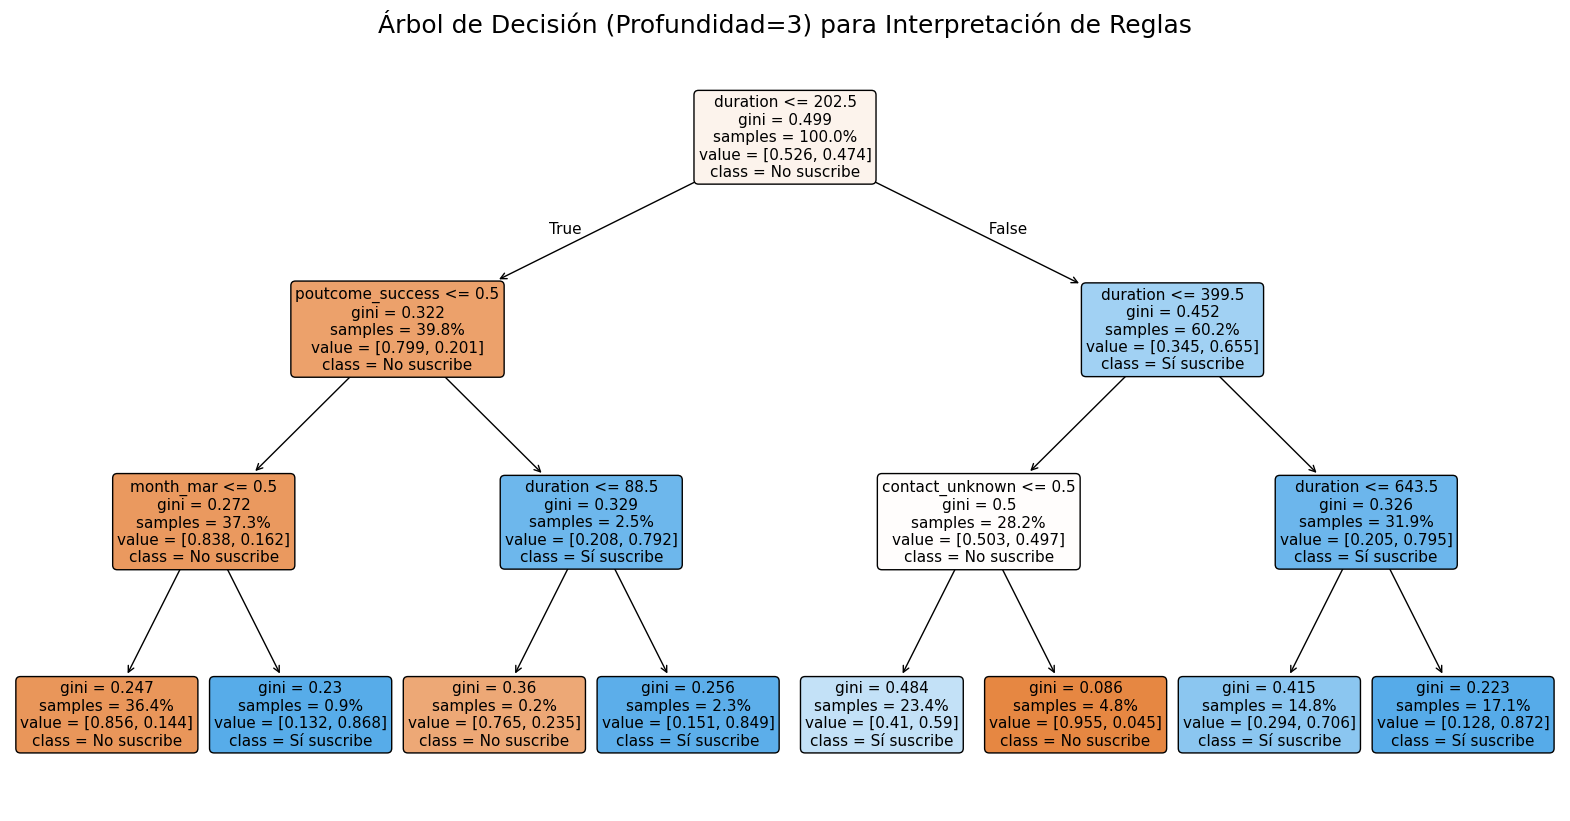

In [27]:
print("--- ENTRENAMIENTO Y VISUALIZACIÓN DE ÁRBOL POCO PROFUNDO ---")

#Definimos un árbol limitado a 3 niveles de profundidad
arbol_interpretable = DecisionTreeClassifier(max_depth=3, random_state=NIA)

#Creamos la pipeline usando el mismo preprocesador de árboles que antes
pipeline_interpretable = Pipeline(steps=[   
    ('preprocesamiento', preprocessor_tree),
    ('clasificador', arbol_interpretable)
])

#Entrenamos el modelo con todo el conjunto de X_train
#No usamos CV porque no estamos evaluando
pipeline_interpretable.fit(X_train, y_train)
preprocesador = pipeline_interpretable.named_steps['preprocesamiento']
nombres_cat = preprocesador.named_transformers_['cat'].get_feature_names_out(columnas_categoricas)
todos_los_nombres = list(columnas_numericas) + list(nombres_cat)

#Dibujamos el árbol
plt.figure(figsize=(20,10))
plot_tree(
    pipeline_interpretable.named_steps['clasificador'], 
    feature_names=todos_los_nombres, 
    class_names=['No suscribe', 'Sí suscribe'], 
    filled=True, 
    rounded=True,
    fontsize=11,
    proportion=True
)
plt.title("Árbol de Decisión (Profundidad=3) para Interpretación de Reglas", fontsize=18)
plt.show()

**Interpretación del Árbol de Decisión**

Al visualizar el árbol con profundidad máxima de 3, podemos extraer reglas de negocio muy claras e interpretables sobre el comportamiento de los clientes:

**1.La duración es clave:** La variable más discriminante (el nodo raíz) es `duration`. Los clientes con llamadas cortas (menores a 206 segundos) tienden mayoritariamente a rechazar el depósito, mientras que llamadas más largas indican un interés claro y derivan en suscripciones.

**2.El impacto del preprocesamiento:** En el segundo nivel de decisión del árbol, observamos que el modelo utiliza intensivamente la variable `contactado_antes` (el umbral     <= 0.5 separa los ceros de los unos). Esta es la variable binaria que creamos durante el EDA para solucionar el problema de la variable `pdays`. Esto confirma que nuestra estrategia fue acertada y aporta gran valor predictivo al modelo.

**3.Otras variables relevantes:** En niveles inferiores, el árbol también se apoya en variables como tener un préstamo hipotecario (`housing_yes`) o el éxito de la campaña anterior (`poutcome_success`) para refinar la predicción.

## 4) Ajuste de hiperparámetros de KNN

Una vez elegido `StandardScaler` como el mejor escalador para KNN, hemos realizado una búsqueda en rejilla para ajustar sus hiperparámetros más importantes dentro de una `Pipeline` completa con preprocesamiento.

En concreto, hemos probado distintos valores de:

- `n_neighbors`, para controlar cuántos vecinos participan en la predicción.
- `weights`, para comparar voto uniforme frente a voto ponderado por distancia.
- `p`, para distinguir entre distancia Manhattan (`p=1`) y Euclídea (`p=2`).

El mejor resultado se ha obtenido con `n_neighbors = 21`, `weights = 'distance'` y `p = 2`, alcanzando una `accuracy` media de aproximadamente **0.8106**. Frente al KNN por defecto, cuya `accuracy` era **0.8016**, la mejora es real pero moderada.

Por tanto, en este problema el ajuste de hiperparámetros mejora ligeramente el rendimiento de KNN, aunque el coste total de la búsqueda es bastante mayor que el de entrenar una única configuración.

In [28]:

print("--- HPO DE KNN ---")

# Preprocesado para KNN: escalado numérico + one hot en categóricas
preprocessor_knn_hpo = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), columnas_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore'), columnas_categoricas)
    ]
)

# Pipeline completa
pipeline_knn_hpo = Pipeline(steps=[
    ('preprocesamiento', preprocessor_knn_hpo),
    ('clasificador', KNeighborsClassifier())
])

# Rejilla de hiperparámetros
param_grid_knn = {
    'clasificador__n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'clasificador__weights': ['uniform', 'distance'],
    'clasificador__p': [1, 2]
}

# Búsqueda con validación cruzada
start_time = time.time()

grid_knn = GridSearchCV(
    estimator=pipeline_knn_hpo,
    param_grid=param_grid_knn,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

grid_knn.fit(X_train, y_train)

tiempo_total_knn = time.time() - start_time

# Resultados
cv_results_knn = pd.DataFrame(grid_knn.cv_results_)
best_idx_knn = grid_knn.best_index_

resumen_knn_hpo = pd.DataFrame({
    'Modelo': ['KNN ajustado'],
    'Best CV accuracy': [grid_knn.best_score_],
    'Best params': [str(grid_knn.best_params_)],
    'Tiempo total HPO (s)': [tiempo_total_knn],
    'Mean fit time mejor config (s)': [cv_results_knn.loc[best_idx_knn, 'mean_fit_time']]
})

display(resumen_knn_hpo)

display(
    cv_results_knn[
        [
            'param_clasificador__n_neighbors',
            'param_clasificador__weights',
            'param_clasificador__p',
            'mean_test_score',
            'std_test_score',
            'rank_test_score',
            'mean_fit_time'
        ]
    ]
    .sort_values('rank_test_score')
    .head(10)
)

best_knn_hpo = grid_knn.best_estimator_

--- HPO DE KNN ---


,Modelo,Best CV accuracy,Best params,Tiempo total HPO (s),Mean fit time mejor config (s)
0,KNN ajustado,0.810585,"{'clasificador__n_neighbors': 21, 'clasificado...",33.036408,0.066993


,param_clasificador__n_neighbors,param_clasificador__weights,param_clasificador__p,mean_test_score,std_test_score,rank_test_score,mean_fit_time
27,21,distance,2,0.810585,0.008804,1,0.066993
23,15,distance,2,0.810178,0.009520,2,0.061275
19,11,distance,2,0.810042,0.008947,3,0.069773
15,9,distance,2,0.809364,0.010159,4,0.060558
26,21,uniform,2,0.807464,0.009939,5,0.056978
18,11,uniform,2,0.806922,0.009202,6,0.065179
22,15,uniform,2,0.806786,0.010772,7,0.066031
14,9,uniform,2,0.806244,0.010954,8,0.051840
11,7,distance,2,0.804343,0.007219,9,0.070807
7,5,distance,2,0.804072,0.007769,10,0.032426


## 5) Ajuste de hiperparámetros de árboles de decisión

En el caso de los árboles de decisión, hemos ajustado los hiperparámetros más importantes mediante `GridSearchCV`, manteniendo el preprocesamiento adecuado para este tipo de modelo: las variables numéricas se dejan sin escalar y las categóricas se codifican con `OneHotEncoder`.

Los hiperparámetros explorados han sido:

- `criterion`, para comparar `gini` y `entropy`.
- `max_depth`, para controlar la profundidad máxima del árbol.
- `min_samples_split`, para regular cuándo puede dividirse un nodo.
- `min_samples_leaf`, para imponer un tamaño mínimo en las hojas.

La mejor configuración encontrada ha sido `criterion = 'gini'`, `max_depth = 10`, `min_samples_split = 50` y `min_samples_leaf = 5`, con una `accuracy` media de aproximadamente **0.8232**.

Este resultado mejora de forma clara al árbol por defecto, que obtenía una `accuracy` de **0.7894**. Por tanto, en árboles sí observamos que el ajuste de hiperparámetros aporta una ganancia importante, especialmente cuando se combina una profundidad relativamente alta con cierta regularización.

In [13]:
print("--- HPO DE ÁRBOL DE DECISIÓN ---")

# Preprocesado para árboles: numéricas sin escalar + one hot en categóricas
preprocessor_tree_hpo = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', columnas_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore'), columnas_categoricas)
    ]
)

# Pipeline completa
pipeline_tree_hpo = Pipeline(steps=[
    ('preprocesamiento', preprocessor_tree_hpo),
    ('clasificador', DecisionTreeClassifier(random_state=NIA))
])

# Rejilla de hiperparámetros
param_grid_tree = {
    'clasificador__criterion': ['gini', 'entropy'],
    'clasificador__max_depth': [3, 5, 7, 10, None],
    'clasificador__min_samples_split': [2, 10, 20, 50],
    'clasificador__min_samples_leaf': [1, 2, 5, 10]
}

# Búsqueda con validación cruzada
start_time = time.time()

grid_tree = GridSearchCV(
    estimator=pipeline_tree_hpo,
    param_grid=param_grid_tree,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

grid_tree.fit(X_train, y_train)

tiempo_total_tree = time.time() - start_time

# Resultados
cv_results_tree = pd.DataFrame(grid_tree.cv_results_)
best_idx_tree = grid_tree.best_index_

resumen_tree_hpo = pd.DataFrame({
    'Modelo': ['Decision Tree ajustado'],
    'Best CV accuracy': [grid_tree.best_score_],
    'Best params': [str(grid_tree.best_params_)],
    'Tiempo total HPO (s)': [tiempo_total_tree],
    'Mean fit time mejor config (s)': [cv_results_tree.loc[best_idx_tree, 'mean_fit_time']]
})

display(resumen_tree_hpo)

display(
    cv_results_tree[
        [
            'param_clasificador__criterion',
            'param_clasificador__max_depth',
            'param_clasificador__min_samples_split',
            'param_clasificador__min_samples_leaf',
            'mean_test_score',
            'std_test_score',
            'rank_test_score',
            'mean_fit_time'
        ]
    ]
    .sort_values('rank_test_score')
    .head(10)
)

best_tree_hpo = grid_tree.best_estimator_

--- HPO DE ÁRBOL DE DECISIÓN ---


,Modelo,Best CV accuracy,Best params,Tiempo total HPO (s),Mean fit time mejor config (s)
0,Decision Tree ajustado,0.823202,"{'clasificador__criterion': 'gini', 'clasifica...",14.18517,0.100022


,param_clasificador__criterion,param_clasificador__max_depth,param_clasificador__min_samples_split,param_clasificador__min_samples_leaf,mean_test_score,std_test_score,rank_test_score,mean_fit_time
59,gini,10,50,5,0.823202,0.003547,1,0.100022
75,gini,None,50,5,0.822523,0.005544,2,0.101197
51,gini,10,50,1,0.822389,0.005378,3,0.130348
55,gini,10,50,2,0.821846,0.003645,4,0.093050
79,gini,None,50,10,0.819132,0.005328,5,0.095953
63,gini,10,50,10,0.818861,0.004877,6,0.100642
135,entropy,10,50,2,0.818726,0.005934,7,0.183497
71,gini,None,50,2,0.818725,0.003346,8,0.122041
131,entropy,10,50,1,0.818590,0.006380,9,0.231676
139,entropy,10,50,5,0.817504,0.004175,10,0.193276


## 6) Efecto de los hiperparámetros en el rendimiento

Una vez obtenidos los resultados del ajuste, analizamos mediante gráficos cómo influyen los hiperparámetros en el rendimiento de KNN y de los árboles de decisión.

En KNN nos interesa observar sobre todo el efecto de `n_neighbors`, del tipo de ponderación (`weights`) y de la métrica empleada (`p`). En árboles, los parámetros más relevantes son `max_depth`, `criterion` y, como mecanismo de regularización, `min_samples_leaf`.

Estos gráficos no solo permiten identificar la mejor configuración, sino también entender qué tendencias generales aparecen en cada método y si el rendimiento mejora de forma estable o solo en combinaciones muy concretas.

--- 4.2.d EFECTO DE LOS HIPERPARÁMETROS ---


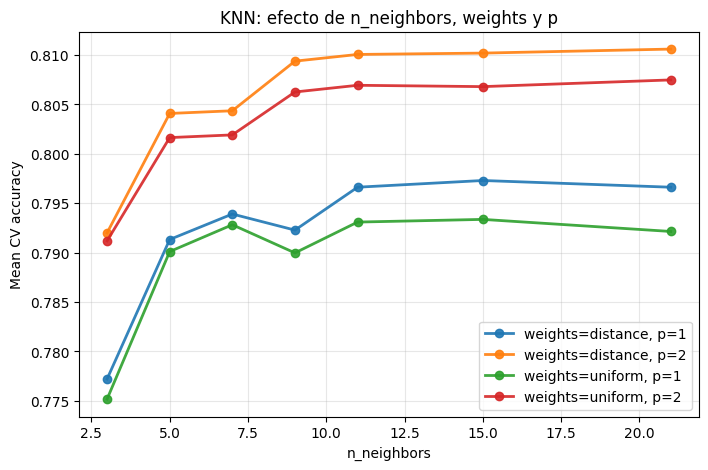

,n_neighbors,weights,p,mean_test_score
25,21,distance,2,0.810585
21,15,distance,2,0.810178
17,11,distance,2,0.810042
13,9,distance,2,0.809364
27,21,uniform,2,0.807464
19,11,uniform,2,0.806922
23,15,uniform,2,0.806786
15,9,uniform,2,0.806244
9,7,distance,2,0.804343
5,5,distance,2,0.804072


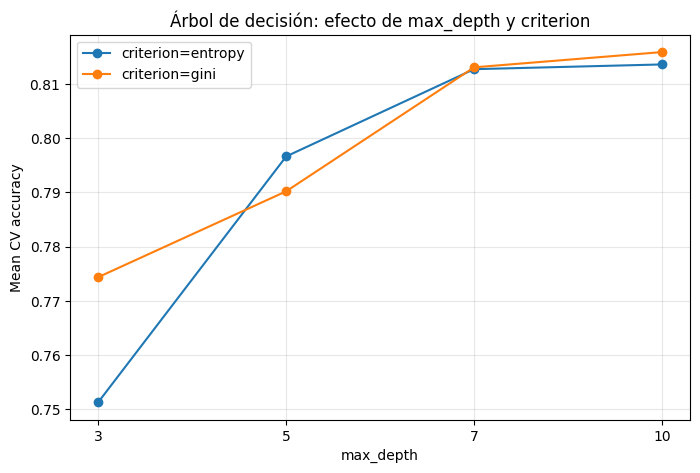

,max_depth,criterion,mean_test_score
1,10,gini,0.815909
0,10,entropy,0.813629
7,7,gini,0.813093
6,7,entropy,0.812755
4,5,entropy,0.796658
5,5,gini,0.790222
3,3,gini,0.774388
2,3,entropy,0.751325


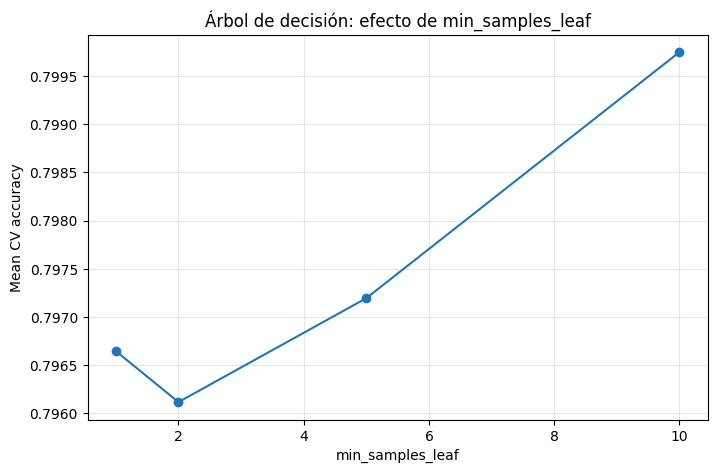

,min_samples_leaf,mean_test_score
0,1,0.796645
1,2,0.796116
2,5,0.797195
3,10,0.799749


In [33]:
import pandas as pd
import matplotlib.pyplot as plt

print("--- 4.2.d EFECTO DE LOS HIPERPARÁMETROS ---")

# ==========
# KNN
# ==========
knn_plot_df = cv_results_knn.copy()

knn_plot_df["n_neighbors"] = knn_plot_df["param_clasificador__n_neighbors"].astype(int)
knn_plot_df["weights"] = knn_plot_df["param_clasificador__weights"].astype(str)
knn_plot_df["p"] = knn_plot_df["param_clasificador__p"].astype(int)

# Accuracy media agrupada por n_neighbors, weights y p
knn_grouped = (
    knn_plot_df
    .groupby(["n_neighbors", "weights", "p"], as_index=False)["mean_test_score"]
    .mean()
)

plt.figure(figsize=(8, 5))
for (weights, p), subdf in knn_grouped.groupby(["weights", "p"]):
    subdf = subdf.sort_values(by="n_neighbors")
    
    estilo = "-" 
    
    plt.plot(
        subdf["n_neighbors"],
        subdf["mean_test_score"],
        marker="o",
        linestyle=estilo,
        linewidth=2,
        alpha=0.9,
        label=f"weights={weights}, p={p}"
    )

plt.xlabel("n_neighbors")
plt.ylabel("Mean CV accuracy")
plt.title("KNN: efecto de n_neighbors, weights y p")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

display(knn_grouped.sort_values(by="mean_test_score", ascending=False).head(10))


# ==========
# TREE
# ==========
tree_plot_df = cv_results_tree.copy()

tree_plot_df["criterion"] = tree_plot_df["param_clasificador__criterion"].astype(str)
tree_plot_df["max_depth"] = tree_plot_df["param_clasificador__max_depth"].astype(str)
tree_plot_df["min_samples_leaf"] = tree_plot_df["param_clasificador__min_samples_leaf"].astype(int)

# Accuracy media agrupada por max_depth y criterion
tree_grouped_depth = (
    tree_plot_df
    .groupby(["max_depth", "criterion"], as_index=False)["mean_test_score"]
    .mean()
)

# Orden manual para max_depth
orden_depth = ["3", "5", "7", "10", "None"]
tree_grouped_depth["max_depth"] = pd.Categorical(
    tree_grouped_depth["max_depth"],
    categories=orden_depth,
    ordered=True
)
tree_grouped_depth = tree_grouped_depth.sort_values(by="max_depth")

plt.figure(figsize=(8, 5))
for criterion, subdf in tree_grouped_depth.groupby("criterion"):
    plt.plot(
        subdf["max_depth"].astype(str),
        subdf["mean_test_score"],
        marker="o",
        label=f"criterion={criterion}"
    )

plt.xlabel("max_depth")
plt.ylabel("Mean CV accuracy")
plt.title("Árbol de decisión: efecto de max_depth y criterion")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

display(tree_grouped_depth.sort_values(by="mean_test_score", ascending=False).head(10))


# ==========
# EXTRA OPCIONAL: min_samples_leaf
# ==========
tree_grouped_leaf = (
    tree_plot_df
    .groupby("min_samples_leaf", as_index=False)["mean_test_score"]
    .mean()
    .sort_values(by="min_samples_leaf")
)

plt.figure(figsize=(8, 5))
plt.plot(
    tree_grouped_leaf["min_samples_leaf"],
    tree_grouped_leaf["mean_test_score"],
    marker="o"
)
plt.xlabel("min_samples_leaf")
plt.ylabel("Mean CV accuracy")
plt.title("Árbol de decisión: efecto de min_samples_leaf")
plt.grid(True, alpha=0.3)
plt.show()

display(tree_grouped_leaf)

**Interpretación de los gráficos**

En **KNN** se observa que los mejores resultados aparecen cuando se utiliza distancia Euclídea (`p = 2`) y ponderación por distancia (`weights = 'distance'`). Además, el rendimiento mejora al aumentar el número de vecinos, siendo los valores altos, especialmente entre **11 y 21**, los que ofrecen mejores resultados. Esto sugiere que, en este problema, KNN se beneficia de decisiones más suavizadas y menos sensibles al ruido local.

En **árboles de decisión**, la profundidad máxima tiene un efecto claro sobre el rendimiento. Los árboles demasiado poco profundos, como los de profundidad 3 o 5, se quedan cortos y rinden peor, mientras que valores alrededor de **10** ofrecen los mejores resultados. Por tanto, el problema parece necesitar árboles con cierta complejidad, aunque no completamente descontrolados.

También se aprecia que introducir regularización mediante `min_samples_leaf` y `min_samples_split` ayuda a mejorar la generalización. En conjunto, los resultados indican que el mejor árbol no es el más simple, pero tampoco uno sin restricciones.

## Conclusiones de los métodos básicos

Para cerrar esta sección, comparamos el rendimiento de los modelos básicos estudiados: `DummyClassifier`, KNN por defecto, árbol por defecto, KNN ajustado y árbol ajustado.

La comparación se realiza utilizando la `accuracy` media obtenida en la evaluación interna y el tiempo medio de entrenamiento. A partir de esta tabla podemos responder a las preguntas clave del apartado: qué método funciona mejor, cuánto cuesta computacionalmente, si realmente mejoran frente a un modelo trivial y si el ajuste de hiperparámetros compensa.

In [34]:
print("--- 4.3 COMPARACIÓN FINAL DE MÉTODOS BÁSICOS ---")

# Por seguridad
NIA = 100495927
columnas_numericas = X_train.select_dtypes(include=['int32', 'int64', 'float64']).columns.tolist()
columnas_categoricas = X_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

# Pipeline Dummy
preprocessor_dummy = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', columnas_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore'), columnas_categoricas)
    ]
)

pipeline_dummy = Pipeline(steps=[
    ('preprocesamiento', preprocessor_dummy),
    ('clasificador', DummyClassifier(strategy='most_frequent'))
])

# Pipeline KNN por defecto
preprocessor_knn_default = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), columnas_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore'), columnas_categoricas)
    ]
)

pipeline_knn_default = Pipeline(steps=[
    ('preprocesamiento', preprocessor_knn_default),
    ('clasificador', KNeighborsClassifier())
])

# Pipeline Tree por defecto
preprocessor_tree_default = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', columnas_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore'), columnas_categoricas)
    ]
)

pipeline_tree_default = Pipeline(steps=[
    ('preprocesamiento', preprocessor_tree_default),
    ('clasificador', DecisionTreeClassifier(random_state=NIA))
])

# Evaluación de modelos por defecto y dummy
res_dummy = cross_validate(
    pipeline_dummy, X_train, y_train,
    cv=cv, scoring='accuracy', n_jobs=-1
)

res_knn_default = cross_validate(
    pipeline_knn_default, X_train, y_train,
    cv=cv, scoring='accuracy', n_jobs=-1
)

res_tree_default = cross_validate(
    pipeline_tree_default, X_train, y_train,
    cv=cv, scoring='accuracy', n_jobs=-1
)

# Tabla final
tabla_final_basicos = pd.DataFrame({
    'Modelo': [
        'DummyClassifier',
        'KNN por defecto',
        'Decision Tree por defecto',
        'KNN ajustado (HPO)',
        'Decision Tree ajustado (HPO)'
    ],
    'CV accuracy media': [
        res_dummy['test_score'].mean(),
        res_knn_default['test_score'].mean(),
        res_tree_default['test_score'].mean(),
        grid_knn.best_score_,
        grid_tree.best_score_
    ],
    'Desv. típica CV': [
        res_dummy['test_score'].std(),
        res_knn_default['test_score'].std(),
        res_tree_default['test_score'].std(),
        cv_results_knn.loc[grid_knn.best_index_, 'std_test_score'],
        cv_results_tree.loc[grid_tree.best_index_, 'std_test_score']
    ],
    'Tiempo medio fit (s)': [
        res_dummy['fit_time'].mean(),
        res_knn_default['fit_time'].mean(),
        res_tree_default['fit_time'].mean(),
        cv_results_knn.loc[grid_knn.best_index_, 'mean_fit_time'],
        cv_results_tree.loc[grid_tree.best_index_, 'mean_fit_time']
    ]
}).sort_values('CV accuracy media', ascending=False)

display(tabla_final_basicos)

# Resumen automático para ayudar a redactar conclusiones
mejor_modelo = tabla_final_basicos.iloc[0]
peor_tiempo = tabla_final_basicos.sort_values('Tiempo medio fit (s)', ascending=False).iloc[0]
mejor_dummy = tabla_final_basicos[tabla_final_basicos['Modelo'] == 'DummyClassifier'].iloc[0]
knn_default_acc = tabla_final_basicos[tabla_final_basicos['Modelo'] == 'KNN por defecto']['CV accuracy media'].values[0]
knn_hpo_acc = tabla_final_basicos[tabla_final_basicos['Modelo'] == 'KNN ajustado (HPO)']['CV accuracy media'].values[0]
tree_default_acc = tabla_final_basicos[tabla_final_basicos['Modelo'] == 'Decision Tree por defecto']['CV accuracy media'].values[0]
tree_hpo_acc = tabla_final_basicos[tabla_final_basicos['Modelo'] == 'Decision Tree ajustado (HPO)']['CV accuracy media'].values[0]

print("Mejor modelo en accuracy:", mejor_modelo['Modelo'])
print("Accuracy media del mejor modelo:", round(mejor_modelo['CV accuracy media'], 4))
print("Modelo con mayor coste de entrenamiento:", peor_tiempo['Modelo'])
print("Tiempo medio de fit:", round(peor_tiempo['Tiempo medio fit (s)'], 4), "s")
print("Accuracy del DummyClassifier:", round(mejor_dummy['CV accuracy media'], 4))
print("Mejora KNN tras HPO:", round(knn_hpo_acc - knn_default_acc, 4))
print("Mejora Tree tras HPO:", round(tree_hpo_acc - tree_default_acc, 4))

--- 4.3 COMPARACIÓN FINAL DE MÉTODOS BÁSICOS ---


,Modelo,CV accuracy media,Desv. típica CV,Tiempo medio fit (s)
4,Decision Tree ajustado (HPO),0.823202,0.003547,0.100022
3,KNN ajustado (HPO),0.810585,0.008804,0.066993
1,KNN por defecto,0.801629,0.007880,0.042319
2,Decision Tree por defecto,0.789417,0.002729,0.078079
0,DummyClassifier,0.525509,0.000101,0.033132


Mejor modelo en accuracy: Decision Tree ajustado (HPO)
Accuracy media del mejor modelo: 0.8232
Modelo con mayor coste de entrenamiento: Decision Tree ajustado (HPO)
Tiempo medio de fit: 0.1 s
Accuracy del DummyClassifier: 0.5255
Mejora KNN tras HPO: 0.009
Mejora Tree tras HPO: 0.0338


**Conclusiones finales**

El mejor método básico ha sido el **árbol de decisión ajustado**, con una `accuracy` media de aproximadamente **0.8232**, superando tanto al KNN ajustado (**0.8106**) como a las versiones por defecto de ambos modelos.

Además, todos los modelos entrenados mejoran claramente al `DummyClassifier`, que se queda en torno a **0.5255**, por lo que podemos concluir que los métodos estudiados están capturando estructura real del problema y no solo reproduciendo la clase mayoritaria.

En cuanto al ajuste de hiperparámetros, en **KNN** la mejora respecto al valor por defecto existe, pero es pequeña, pasando de **0.8016** a **0.8106**. En cambio, en **árboles de decisión** la mejora es mucho más clara, ya que se pasa de **0.7894** a **0.8232**.

Desde el punto de vista computacional, el tiempo medio de entrenamiento de las mejores configuraciones sigue siendo bajo, pero el coste total del proceso de búsqueda sí aumenta de forma notable, especialmente en KNN. Aun así, en el caso de los árboles este coste adicional queda más justificado, porque la mejora en rendimiento es bastante mayor.

En resumen, dentro de los métodos básicos, la opción más sólida para este problema es el **árbol de decisión ajustado**.